## Часть 1. Классификатор 128×128
- Требования к модели:
  - Своя архитектура (разрешается вдохновляться CNN-идеями: Conv-BN-ReLU, блоки с даунсемплингом, GAP и т.д.).
  - Ограничение на параметризованность: не более ~5M параметров.
  - Вход: 128×128×3.
  - Можно выбрать любое количество классов для обучения!
- Обучение:
  - Трен/вал сплит: выберите собственную стратификацию.
  - Аугментации: разумные (кроп, флипы, color jitter и т.д.), кратко опишите в отчёте.
- Что сдаём по части 1:
  - График/лог обучения (loss/accuracy по эпохам) и итоговые метрики на валидации.
  - Чекпоинт модели (по возможности) или веса/ссылка.

### Приведение tiny-image-net к 128x128 размерности

In [1]:
import os
import shutil
from PIL import Image
from tqdm import tqdm
from pathlib import Path

def resize_tinyimagenet_dataset(input_path, output_path=None, size=(128, 128)):
    """
    Resize all images in TinyImageNet dataset to specified size and copy all other files.
    
    Args:
        input_path: Path to the original dataset folder
        output_path: Path to save resized dataset (if None, creates 'tiny-imagenet-200_resized')
        size: Target size as (width, height)
    """
    input_path = Path(input_path)
    
    # Set default output path if not provided
    if output_path is None:
        output_path = input_path.parent / f"{input_path.name}_resized"
    else:
        output_path = Path(output_path)

    if os.path.exists(output_path):
        return output_path
    
    print(f"Processing dataset from: {input_path}")
    print(f"Saving to: {output_path}")
    print(f"Target image size: {size}")
    print("-" * 50)
    
    # Define image extensions
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff', '.tif'}
    
    # Count total files first
    print("Counting files...")
    all_files = []
    for root, dirs, files in os.walk(input_path):
        for file in files:
            file_path = Path(root) / file
            rel_path = file_path.relative_to(input_path)
            all_files.append((root, file, rel_path))
    
    total_files = len(all_files)
    print(f"Found {total_files} total files.")
    
    # Process files
    processed_images = 0
    copied_files = 0
    failed_files = 0
    
    with tqdm(total=total_files, desc="Processing files") as pbar:
        for root, file, rel_path in all_files:
            file_path = Path(root) / file
            output_file = output_path / rel_path
            
            # Create output directory if it doesn't exist
            output_file.parent.mkdir(parents=True, exist_ok=True)
            
            # Check if file is an image
            is_image = file_path.suffix.lower() in image_extensions
            
            try:
                if is_image:
                    # Resize image
                    img = Image.open(file_path).convert('RGB')
                    img = img.resize(size, Image.Resampling.LANCZOS)
                    img.save(output_file)
                    processed_images += 1
                else:
                    # Copy non-image file
                    shutil.copy2(file_path, output_file)
                    copied_files += 1
                    
            except Exception as e:
                print(f"\nError processing {file_path}: {e}")
                failed_files += 1
                # Try to copy the file anyway if image processing failed
                if is_image:
                    try:
                        shutil.copy2(file_path, output_file)
                        print(f"  -> Copied original instead")
                    except:
                        pass
            
            pbar.update(1)
    
    print("\n" + "=" * 50)
    print("Processing complete!")
    print(f"Total files processed: {total_files}")
    print(f"Images resized: {processed_images}")
    print(f"Non-image files copied: {copied_files}")
    if failed_files > 0:
        print(f"Failed files: {failed_files}")
    print(f"Output dataset saved to: {output_path}")
    print("=" * 50)
    
    # Print a summary of what was copied vs resized
    print("\nFile type summary:")
    print("-" * 30)
    
    # Analyze file types
    file_types = {}
    for root, file, rel_path in all_files:
        file_path = Path(root) / file
        ext = file_path.suffix.lower()
        file_types[ext] = file_types.get(ext, 0) + 1
    
    for ext, count in sorted(file_types.items()):
        if ext in image_extensions:
            print(f"{ext or '(no ext)'}: {count} files (resized)")
        else:
            print(f"{ext or '(no ext)'}: {count} files (copied)")
    
    return output_path


dataset_path = "data/tiny-imagenet-200"  

# Resize all images to 128x128 and copy other files
resized_path = resize_tinyimagenet_dataset(
    input_path=dataset_path,
    output_path=None,  
    size=(128, 128)
)

In [2]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
from matplotlib import pyplot as plt

class TinyImageNetDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None, num_classes=-1):
        super().__init__()

        self.root_dir = root_dir
        self.split = split
        self.transform = transform

        with open(os.path.join(root_dir, 'wnids.txt'), 'r') as f:
            all_class_names = [line.strip() for line in f]

        if num_classes > 0 and num_classes <= len(all_class_names):
            self.class_names = all_class_names[:num_classes]
        else:
            self.class_names = all_class_names

        self.class_to_idx = {name: i for i, name in enumerate(self.class_names)}

        self.samples = []
        if split == 'train':
            train_dir = os.path.join(root_dir, 'train')
            for cls in self.class_names:
                img_dir = os.path.join(train_dir, cls, 'images')
                if not os.path.exists(img_dir):
                    continue
                for img_name in os.listdir(img_dir):
                    img_path = os.path.join(img_dir, img_name)
                    label = self.class_to_idx[cls]
                    self.samples.append((img_path, label))

        elif split == 'val':
            val_dir = os.path.join(root_dir, 'val', 'images')
            anno_path = os.path.join(root_dir, 'val', 'val_annotations.txt')

            label_map = {}
            with open(anno_path, 'r') as f:
                for line in f:
                    img_name, cls, *_ = line.strip().split('\t')
                    label_map[img_name] = cls

            for img_name in os.listdir(val_dir):
                cls = label_map.get(img_name)
                if cls and cls in self.class_to_idx:
                    img_path = os.path.join(val_dir, img_name)
                    label = self.class_to_idx[cls]
                    self.samples.append((img_path, label))

        else:
            test_dir = os.path.join(root_dir, 'test', 'images')
            for img_name in os.listdir(test_dir):
                img_path = os.path.join(test_dir, img_name)
                self.samples.append((img_path, -1))  # тест без меток


    def __len__(self):
        return len(self.samples)


    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

/home/kalex/.local/lib/python3.11/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),                    
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),  
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),                     
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

root = "data/tiny-imagenet-200_resized"


train_dataset = TinyImageNetDataset(root, split='train', transform=train_transform, num_classes=10)
val_dataset = TinyImageNetDataset(root, split='val', transform=val_transform, num_classes=10)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=8) # num_workers=>1 does not work on macos
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=8)    # num_workers=>1 does not work on macos

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Классов: {len(train_dataset.class_names)}")

Train size: 5000
Val size: 500
Классов: 10


size:  torch.Size([3, 128, 128])
size:  torch.Size([3, 128, 128])
size:  torch.Size([3, 128, 128])
size:  torch.Size([3, 128, 128])
size:  torch.Size([3, 128, 128])
size:  torch.Size([3, 128, 128])
size:  torch.Size([3, 128, 128])
size:  torch.Size([3, 128, 128])


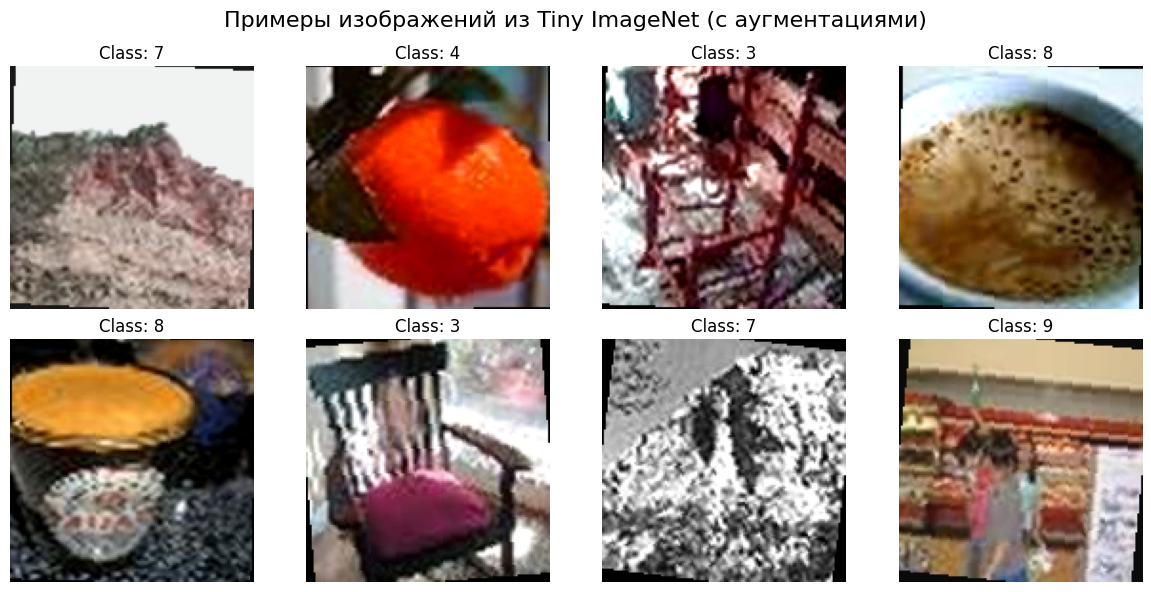

Размер батча: torch.Size([8, 3, 128, 128])
Диапазон значений: [-2.118, 2.640]
Метки классов: [7, 4, 3, 8, 8, 3, 7, 9]
Всего классов в датасете: 10
Примеры названий классов: ['n02124075', 'n04067472', 'n04540053', 'n04099969', 'n07749582']


In [4]:
images, labels = next(iter(train_loader))

def denormalize(img_tensor):
    """Вернём изображение из нормализованного диапазона в [0,1]"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 1, 3)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 1, 3)
    img = img_tensor.permute(1, 2, 0) * std + mean
    print("size: ", img_tensor.shape )
    return img.clamp(0, 1)

images_vis = images.permute(0, 2, 3, 1)

images_vis = torch.stack([denormalize(img) for img in images])

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images_vis[i])
    plt.title(f"Class: {labels[i].item()}")
    plt.axis('off')
plt.suptitle("Примеры изображений из Tiny ImageNet (с аугментациями)", fontsize=16)
plt.tight_layout()
plt.show()

print(f"Размер батча: {images.shape}")
print(f"Диапазон значений: [{images.min():.3f}, {images.max():.3f}]")
print(f"Метки классов: {labels.tolist()}")
print(f"Всего классов в датасете: {len(train_dataset.class_names)}")
print(f"Примеры названий классов: {train_dataset.class_names[:5]}")

### Умная Стратификация

In [5]:
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from collections import Counter
import numpy as np

x = []
y = []

val_fraction = round(len(val_dataset.samples) / (len(val_dataset.samples) + len(train_dataset.samples)), 4)
print("valication fraq: ", val_fraction)

joined_samples = train_dataset.samples + val_dataset.samples
for i, v in enumerate(joined_samples):
    x.append(v[0])
    y.append(v[1])


skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


fold_splits = []

for fold, (train_idx, val_idx) in enumerate(skf.split(x, y)):
    stratified_train_split = [joined_samples[i] for i in train_idx]
    stratified_val_split = [joined_samples[i] for i in val_idx]
    fold_splits.append((stratified_train_split, stratified_val_split))
    print(f"   Fold {fold}: train={len(stratified_train_split)}, val={len(stratified_val_split)}")

print(f" Стратифицированное разделение:")
print(f"   Train: {len(stratified_train_split)} образцов")
print(f"   Val: {len(stratified_val_split)} образцов")


def analyze_class_distribution(samples, name):
    labels = [label for _, label in samples]
    class_counts = Counter(labels)
    print(f" {name} - распределение классов:")
    print(f"   Минимум: {min(class_counts.values())}")
    print(f"   Максимум: {max(class_counts.values())}")
    print(f"   Среднее: {np.mean(list(class_counts.values())):.1f}")
    print(f"   Стандартное отклонение: {np.std(list(class_counts.values())):.1f}")

# Анализируем распределение классов
analyze_class_distribution(stratified_train_split, "Стратифицированное train")
analyze_class_distribution(stratified_val_split, "Стратифицированное val")

valication fraq:  0.0909
   Fold 0: train=4950, val=550
   Fold 1: train=4950, val=550
   Fold 2: train=4950, val=550
   Fold 3: train=4950, val=550
   Fold 4: train=4950, val=550
   Fold 5: train=4950, val=550
   Fold 6: train=4950, val=550
   Fold 7: train=4950, val=550
   Fold 8: train=4950, val=550
   Fold 9: train=4950, val=550
 Стратифицированное разделение:
   Train: 4950 образцов
   Val: 550 образцов
 Стратифицированное train - распределение классов:
   Минимум: 495
   Максимум: 495
   Среднее: 495.0
   Стандартное отклонение: 0.0
 Стратифицированное val - распределение классов:
   Минимум: 55
   Максимум: 55
   Среднее: 55.0
   Стандартное отклонение: 0.0


In [6]:
from torch import nn

class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, activation=nn.ReLU(inplace=True)):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.activation = activation

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = nn.Identity()
        if in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, padding=0),
                nn.BatchNorm2d(out_channels)
            )



    def forward(self, x):
        x_ident = self.downsample(x)

        out = self.activation(self.bn1(self.conv1(x)))
        
        out = self.bn2(self.conv2(out))

        out += x_ident
        out = self.activation(out)

        return out


class CustomResNetBuilder(nn.Module):
    def __init__(self, custom_block=BasicBlock, layer_shape=[2, 2, 2, 2], activation=nn.ReLU(inplace=True), num_classes=200):
        super().__init__()

        self.custom_block = custom_block
        self.layer_shape = layer_shape
        self.activation = activation
        self.num_classes = num_classes

        # Initial convolution
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(2)

        # Define channel dimensions for each stage
        self.in_channels = 64
        channels = [64, 128, 256, 512]

        # Create layers dynamically
        self.layers = nn.ModuleList()

        # Create each stage
        for i, (num_blocks, out_channels) in enumerate(zip(layer_shape, channels)):
            # First block in the stage might need to handle stride/dimension changes
            stride = 2 if i > 0 else 1  # Downsample in first block of stage 2,3,4

            # Create blocks for this stage
            stage_blocks = []
            for j in range(num_blocks):
                # For the first block in stage (except stage 0), use stride=2
                block_stride = stride if j == 0 else 1

                # Create the block
                block = custom_block(
                    in_channels=self.in_channels,
                    out_channels=out_channels,
                    stride=block_stride,
                    activation=activation
                )
                stage_blocks.append(block)

                # Update in_channels for next block
                self.in_channels = out_channels

            # Add all blocks for this stage
            self.layers.extend(stage_blocks)

        # Adaptive pooling and final layer
        self.adaptive_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(channels[len(layer_shape)-1], num_classes)

    def forward(self, x):
        # Initial convolution
        x = self.activation(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        # Go through all layers
        for layer in self.layers:
            x = layer(x)

        # Final pooling and classification
        x = self.adaptive_pooling(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

    def display(self):
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f" Всего параметров: {total_params:,}")
        print(f" Обучаемых параметров: {trainable_params:,}")

    def params(self):
        return sum(p.numel() for p in self.parameters())

###  Заготовки

In [7]:
from tqdm import tqdm
import torch
import gc
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn

def train_epoch(model, train_loader, optimizer, criterion, device):
    """
    Функция для одного эпоха обучения

    Args:
        model: модель для обучения
        train_loader: DataLoader с тренировочными данными
        optimizer: оптимизатор
        criterion: функция потерь
        device: устройство (cpu/cuda)

    Returns:
        train_loss: средняя потеря за эпох
        train_acc: средняя точность за эпох
    """
    model.train()  # Переводим модель в режим обучения

    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc="Training", leave=False)

    for batch_idx, (data, target) in enumerate(pbar):
        # Перемещаем данные на устройство
        data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)

        # Обнуляем градиенты
        optimizer.zero_grad(set_to_none=True)  # Более эффективное обнуление градиентов

        # Прямой проход
        outputs = model(data)

        # Вычисление потерь
        loss = criterion(outputs, target)

        # Обратный проход
        loss.backward()

        # Шаг оптимизатора
        optimizer.step()

        # Статистика
        running_loss += loss.item()

        # Вычисление точности
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

        # Обновление прогресс-бара
        current_loss = running_loss / (batch_idx + 1)
        current_acc = 100.0 * correct / total if total > 0 else 0.0
        pbar.set_postfix({
            'loss': f'{current_loss:.4f}',
            'acc': f'{current_acc:.2f}%'
        })

        # Освобождаем память от промежуточных тензоров
        del outputs, predicted
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    # Вычисление средних значений за эпоху
    train_loss = running_loss / len(train_loader)
    train_acc = 100.0 * correct / total if total > 0 else 0.0

    return train_loss, train_acc



def validate_epoch(model, val_loader, criterion, device):
    """
    Функция для валидации модели

    Args:
        model: модель для валидации
        val_loader: DataLoader с валидационными данными
        criterion: функция потерь
        device: устройство (cpu/cuda)

    Returns:
        val_loss: средняя потеря на валидации
        val_acc: средняя точность на валидации
    """
    model.eval()  # Переводим модель в режим оценки

    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():  # Отключаем вычисление градиентов
        for batch_idx, (data, target) in enumerate(pbar):
            # Перемещаем данные на устройство
            data, target = data.to(device, non_blocking=True), target.to(device, non_blocking=True)

            # Прямой проход
            outputs = model(data)

            # Вычисление потерь
            loss = criterion(outputs, target)
            running_loss += loss.item()

            # Вычисление точности
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

            # Обновление прогресс-бара
            current_loss = running_loss / (batch_idx + 1)
            current_acc = 100.0 * correct / total if total > 0 else 0.0
            pbar.set_postfix({
                'loss': f'{current_loss:.4f}',
                'acc': f'{current_acc:.2f}%'
            })

            # Освобождаем память
            del outputs, predicted
            torch.cuda.empty_cache() if torch.cuda.is_available() else None

    # Вычисление средних значений
    val_loss = running_loss / len(val_loader)
    val_acc = 100.0 * correct / total if total > 0 else 0.0

    return val_loss, val_acc



def train_model(model, train_loader, val_loader, optimizer, criterion, device, num_epochs=10):
    """
    Основная функция для обучения модели

    Args:
        model: модель для обучения
        train_loader: DataLoader с тренировочными данными
        val_loader: DataLoader с валидационными данными
        optimizer: оптимизатор
        criterion: функция потерь
        device: устройство (cpu/cuda)
        num_epochs: количество эпох

    Returns:
        history: словарь с историей обучения
    """
    print(f"Обучение на {num_epochs} эпох...")

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    model = model.to(device)

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        print(f"\nЭпоха {epoch+1}/{num_epochs}")

        # Очистка памяти перед каждой эпохой
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)

        # Очистка памяти перед валидацией
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()

        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f" Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f" Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f" Сохранена лучшая модель с точностью {val_acc:.2f}%")

        # Очистка памяти после эпохи
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return history



def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.plot(history['val_loss'], label='Validation Loss', color='red')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history['train_acc'], label='Train Accuracy', color='blue')
    ax2.plot(history['val_acc'], label='Validation Accuracy', color='red')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()
    plt.close(fig)  # Закрываем фигуру для освобождения памяти

def denormalize(img_tensor):
    """Вернём изображение из нормализованного диапазона в [0,1]"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 1, 3)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 1, 3)
    img = img_tensor.permute(1, 2, 0) * std + mean
    return img.clamp(0, 1)

def display_dataset(loader, train_dataset=None):
    images, labels = next(iter(loader))
    
    # Создаем копию на CPU для визуализации
    images_cpu = images.cpu().clone()
    
    images_vis = torch.stack([denormalize(img) for img in images_cpu])

    plt.figure(figsize=(12, 6))
    for i in range(min(8, len(images))):
        plt.subplot(2, 4, i+1)
        plt.imshow(images_vis[i])
        plt.title(f"Class: {labels[i].item()}")
        plt.axis('off')
    plt.suptitle("Примеры изображений из Tiny ImageNet (с аугментациями)", fontsize=16)
    plt.tight_layout()
    plt.show()
    plt.close()

    print(f"Размер батча: {images.shape}")
    print(f"Диапазон значений: [{images.min():.3f}, {images.max():.3f}]")
    print(f"Метки классов: {labels.tolist()}")
    if train_dataset and hasattr(train_dataset, 'class_names'):
        print(f"Всего классов в датасете: {len(train_dataset.class_names)}")
        print(f"Примеры названий классов: {train_dataset.class_names[:5]}")
    
    # Очистка
    del images, labels, images_cpu, images_vis
    gc.collect()



def RunTrainModels(models, model_names=None, train_loader=None,
                   val_loader=None, num_epochs=5, lr=0.001):
    """
    Train multiple models sequentially and plot their training histories.

    Args:
        models: List of model instances
        model_names: List of model names for labeling (optional)
        train_loader: Training data loader
        val_loader: Validation data loader
        num_epochs: Number of epochs to train each model
        lr: Learning rate for optimizer
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    criterion = nn.CrossEntropyLoss()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        gc.collect()

    all_histories = []

    # If model_names not provided, generate default names
    if model_names is None:
        model_names = [f"Model_{i+1}" for i in range(len(models))]

    for idx, (model, model_name) in enumerate(zip(models, model_names)):
        print(f"\n{'='*60}")
        print(f"Training {model_name} ({idx+1}/{len(models)})")
        print(f"{'='*60}")

        # Тщательная очистка памяти перед началом обучения новой модели
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()

        # Move model to device
        model = model.to(device)

        # Count parameters
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Total parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,}")

        # Create optimizer
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        
        # Используем gradient accumulation если модель большая
        if total_params > 50_000_000:  # Если больше 50M параметров
            print("Большая модель - используем gradient clipping")
            for param in model.parameters():
                param.grad = None

        # Train the model
        history = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            num_epochs=num_epochs
        )

        # Store history with model name
        history['model_name'] = model_name
        history['params'] = f"{total_params:,}"

        all_histories.append(history)
        
        # Plot individual training history
        plot_training_history(history)

        # Очистка памяти после каждой модели
        del optimizer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
        
        # Явное удаление модели
        model.cpu()
        del model
        gc.collect()
        
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()

    # Plot comparison of all models
    plot_comparison(all_histories)

    return all_histories



def plot_comparison(histories):
    """
    Plot comparison of multiple models' training histories.

    Args:
        histories: List of history dictionaries from train_model
    """
    if not histories:
        return
        
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    colors = plt.cm.Set3(np.linspace(0, 1, len(histories)))

    # Plot training loss
    ax = axes[0]
    for history, color, model_name in zip(histories, colors, [h['model_name'] for h in histories]):
        if 'train_loss' in history and history['train_loss']:
            ax.plot(history['train_loss'], label=model_name, color=color, linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training Loss')
    ax.set_title('Training Loss Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot validation accuracy
    ax = axes[1]
    for history, color, model_name in zip(histories, colors, [h['model_name'] for h in histories]):
        if 'val_acc' in history and history['val_acc']:
            ax.plot(history['val_acc'], label=model_name, color=color, linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Accuracy (%)')
    ax.set_title('Validation Accuracy Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

    # Print final metrics comparison
    print("\n" + "="*90)
    print("FINAL METRICS COMPARISON")
    print("="*60)
    print(f"{'Model Name':<20} {'Parameters':<20} {'Train Acc (%):':<15}  {'Val Acc (%):':<15} {'Train Loss:'} {'Val Loss:'}")
    print("-"*60)

    for history in histories:
        model_name = history['model_name']

        parameters = history.get('params', 'N/A')

        train_acc = history['train_acc'][-1] if history.get('train_acc') else 0
        val_acc = history['val_acc'][-1] if history.get('val_acc') else 0

        train_loss = history['train_loss'][-1] if history.get('train_loss') else 0
        val_loss = history['val_loss'][-1] if history.get('val_loss') else 0

        print(f"{model_name:<20} {str(parameters):<20}  {train_acc:<15.2f}  {val_acc:<15.2f} {train_loss:<.4f} {val_loss:.4f}")


Training GELU [1, 1, 1, 1] (1/1)
Total parameters: 4,911,818
Trainable parameters: 4,911,818
Обучение на 50 эпох...

Эпоха 1/50


 Train Loss: 2.3217, Train Acc: 19.82%
 Val Loss: 2.2292, Val Acc: 21.82%
 Сохранена лучшая модель с точностью 21.82%

Эпоха 2/50


 Train Loss: 2.0351, Train Acc: 28.55%
 Val Loss: 2.3610, Val Acc: 25.82%
 Сохранена лучшая модель с точностью 25.82%

Эпоха 3/50


 Train Loss: 1.9584, Train Acc: 32.55%
 Val Loss: 1.9973, Val Acc: 35.09%
 Сохранена лучшая модель с точностью 35.09%

Эпоха 4/50


 Train Loss: 1.8623, Train Acc: 35.09%
 Val Loss: 2.0525, Val Acc: 30.55%

Эпоха 5/50


...

 Train Loss: 1.1099, Train Acc: 59.64%
 Val Loss: 1.3270, Val Acc: 55.45%

Эпоха 47/50


 Train Loss: 1.0612, Train Acc: 61.27%
 Val Loss: 1.2572, Val Acc: 55.64%

Эпоха 48/50


 Train Loss: 1.1147, Train Acc: 61.27%
 Val Loss: 1.1965, Val Acc: 60.55%

Эпоха 49/50


 Train Loss: 1.0790, Train Acc: 62.00%
 Val Loss: 1.0433, Val Acc: 63.09%

Эпоха 50/50


 Train Loss: 1.0152, Train Acc: 63.82%
 Val Loss: 0.9906, Val Acc: 64.18%
 Сохранена лучшая модель с точностью 64.18%


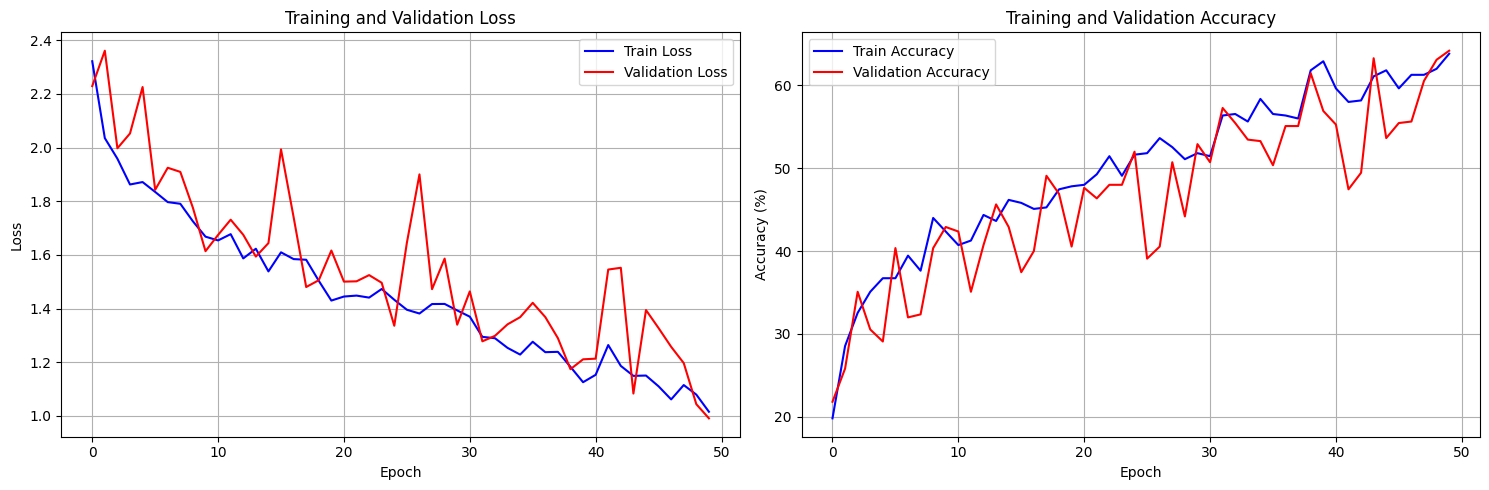

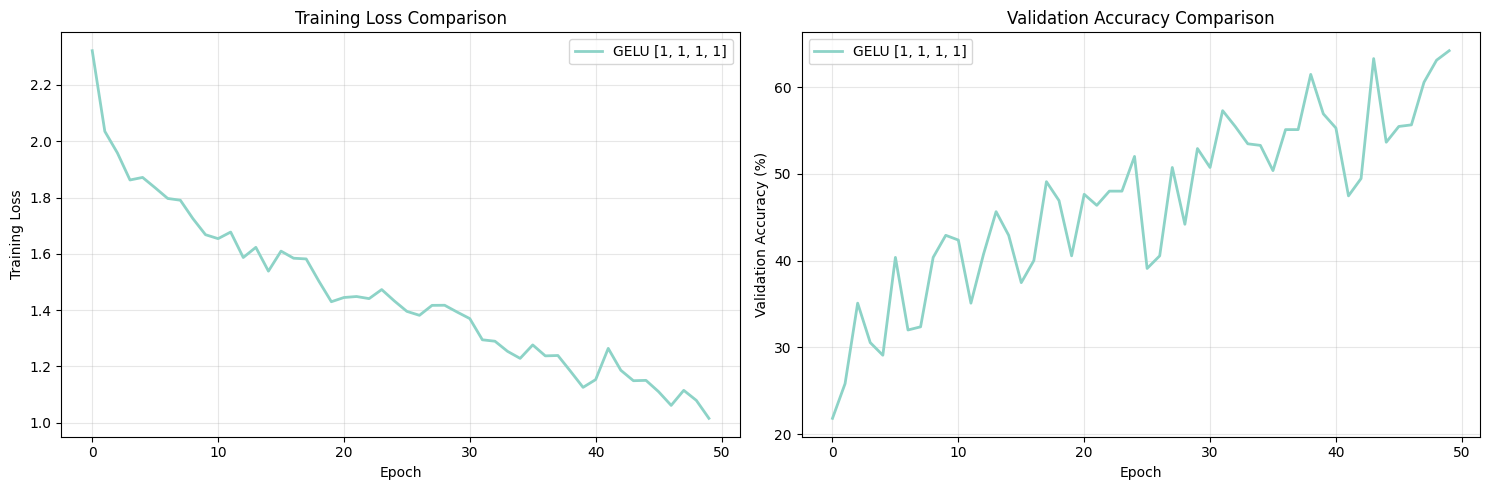


FINAL METRICS COMPARISON
Model Name           Parameters           Train Acc (%):   Val Acc (%):    Train Loss: Val Loss:
------------------------------------------------------------
GELU [1, 1, 1, 1]    4,911,818             63.82            64.18           1.0152 0.9906


In [8]:
stratisfied_train_dataset = train_dataset
stratisfied_val_dataset = train_dataset

stratisfied_train_dataset.samples = stratified_train_split
stratisfied_val_dataset.samples = stratified_val_split

stratisfied_train_loader = DataLoader(stratisfied_train_dataset, batch_size=64, shuffle=True, num_workers=8)
stratisfied_val_loader = DataLoader(stratisfied_val_dataset, batch_size=64, shuffle=False, num_workers=8)   

models = [
    CustomResNetBuilder(activation=nn.GELU(), layer_shape=[1, 1, 1, 1], num_classes=10),
]

# Optional: Provide descriptive names
model_names = [
    "GELU [1, 1, 1, 1]"
]

# Train all models
histories = RunTrainModels(
    models=models,
    model_names=model_names,
    train_loader=stratisfied_train_loader,
    val_loader=stratisfied_val_loader,
    num_epochs=50,
    lr=0.001
)